# Modeling notebook for the computacional variables
---

## The models which were used:
- Ridge
- RandomForest (with two criterions)
- LGBMRegressor

## The metrics to evaluate the models were:
- Root Mean Squared Error (`RMSE`)
- Mean Absolute Error (`MAE`)
- Weight Absolute Percentual Error (`WAPE`)

In [1]:
# ! pip install lightgbm

In [2]:
import pandas as pd
import numpy as np

# from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
# from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [3]:
from pipeline_datapreparation import prepare_dadosset as DataPipeline

In [4]:
def plot_metric_comparison(train, test, title):
    train = pd.DataFrame(train)
    test = pd.DataFrame(test)
    metrics = train.index
    models = train.columns

    colors = {"Treino": "#8E9091", "Teste": "#5B8CC0"}

    x = np.arange(len(models))
    width = 0.35

    fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5), dpi=500)

    for i, metric in enumerate(metrics):
        ax = axes[i]

        train_values = train.loc[metric]
        test_values = test.loc[metric]

        bars_train = ax.bar(x - width/2, train_values, width, color=colors['Treino'], label='Treino')
        bars_test = ax.bar(x + width/2, test_values, width, color=colors['Teste'], label='Teste')
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)

        for bar in bars_train:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height,
                    f'{height:.3f}', ha='center', va='bottom')
        
        for bar in bars_test:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height,
                    f'{height:.3f}', ha='center', va='bottom')
# fontsize=12, fontweight="bold", pad=10
        ax.set_title(metric.upper(), fontdict=dict(fontsize=12, fontweight="bold"), pad=10)
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=0)
        ax.set_ylabel(metric.upper())

    # axes[0].legend()  # legenda só no primeiro para evitar repetição

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
        frameon=False,
    )
    
    fig.suptitle(
        title,
        fontsize=14,
        fontweight="bold",
        y=1.08,
    )

    plt.tight_layout()
    plt.show()
    return fig

In [5]:
def regression_metrics(y_true, y_pred):
    rmse = round(np.sqrt(mean_squared_error(y_true, y_pred)), 3)
    mae = round(mean_absolute_error(y_true, y_pred), 3)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    wape = np.sum(np.abs(y_true - y_pred)) / denom
    return {'rmse':rmse, 'mae':mae, 'wape':round(wape, 3)}

In [6]:
print("Conjunto de Treino")
df_train = DataPipeline(pd.read_csv('dados/train.csv'), treat_outliers=True, create_lags=True)["prepared_data"]
display(df_train.head())

print("Conjunto de Teste")
df_test = DataPipeline(pd.read_csv('dados/test.csv'), treat_outliers=True, create_lags=True)["prepared_data"].iloc[12:]
display(df_test.head())

print(f"Shape conjunto de treino: {df_train.shape}")
print(f"Shape conjunto de teste: {df_test.shape}")

Conjunto de Treino


,HICPOV_PT_ea-md,HICPNEF_PT_ea-md,HICPSV_PT_ea-md,HICPNG_PT_ea-md,GS5_fred-md,CCONFIX_PT_ea-md,REER42_PT_ea-md,EMPENT_PT_ea-qd,PCEPI_fred-md,EXPGS_PT_ea-qd,...,OILPRICEx_fred-md_Eur_lag_2,OILPRICEx_fred-md_Eur_lag_3,OILPRICEx_fred-md_Eur_lag_4,OILPRICEx_fred-md_Eur_lag_5,OILPRICEx_fred-md_Eur_lag_6,OILPRICEx_fred-md_Eur_lag_7,OILPRICEx_fred-md_Eur_lag_12,inflation_target_lag_1,inflation_target_lag_2,inflation_target_lag_3
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,-2.155540,-2.416320,-2.090914,-1.810267,2.651460,1.612561,-2.037451,-1.857311,-1.672367,-1.333886,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-02-01,-2.154871,-2.411396,-2.082324,-1.802991,2.718651,1.557800,-2.347105,-1.854323,-1.652773,-1.348727,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.1,NaN,NaN
2000-03-01,-2.151498,-2.401548,-2.075948,-1.802610,2.597707,1.539546,-2.538577,-1.838577,-1.626023,-1.373899,...,-1.466960,NaN,NaN,NaN,NaN,NaN,NaN,1.8,2.1,NaN
2000-04-01,-2.121278,-2.396454,-2.069746,-1.703956,2.436448,0.991927,-2.414996,-1.805954,-1.631220,-1.394979,...,-1.118196,-1.466960,NaN,NaN,NaN,NaN,NaN,1.5,1.8,2.1
2000-05-01,-2.119912,-2.376889,-2.054342,-1.715435,2.725370,1.101451,-2.394699,-1.761853,-1.626023,-1.402864,...,-0.958600,-1.118196,-1.46696,NaN,NaN,NaN,NaN,2.1,1.5,1.8


Conjunto de Teste


,HICPOV_PT_ea-md,HICPNEF_PT_ea-md,HICPSV_PT_ea-md,HICPNG_PT_ea-md,GS5_fred-md,CCONFIX_PT_ea-md,REER42_PT_ea-md,EMPENT_PT_ea-qd,PCEPI_fred-md,EXPGS_PT_ea-qd,...,OILPRICEx_fred-md_Eur_lag_2,OILPRICEx_fred-md_Eur_lag_3,OILPRICEx_fred-md_Eur_lag_4,OILPRICEx_fred-md_Eur_lag_5,OILPRICEx_fred-md_Eur_lag_6,OILPRICEx_fred-md_Eur_lag_7,OILPRICEx_fred-md_Eur_lag_12,inflation_target_lag_1,inflation_target_lag_2,inflation_target_lag_3
Date,,,,,,,,,,,,,,,,,,,,,
2023-07-01,2.311222,2.273500,2.146303,1.444210,1.011992,-0.075929,-0.341936,2.574181,2.386643,2.135289,...,0.775336,1.009704,0.798917,1.009527,0.981243,0.960468,2.373517,3.4,4.0,5.7
2023-08-01,2.422910,2.356405,2.224553,1.757522,1.126217,-0.176325,-0.305248,2.599608,2.417567,2.090561,...,0.666480,0.775336,1.009704,0.798917,1.009527,0.981243,2.153891,3.1,3.4,4.0
2023-09-01,2.416197,2.294482,2.160515,1.870766,1.247161,-0.577912,-0.255050,2.645049,2.455818,2.066858,...,0.837010,0.666480,0.775336,1.009704,0.798917,1.009527,1.915145,3.7,3.1,3.4
2023-10-01,2.392800,2.313484,2.176974,1.662413,1.435297,-0.687436,-0.488926,2.729573,2.461355,2.077965,...,1.336650,0.837010,0.666480,0.775336,1.009704,0.798917,1.980482,3.6,3.7,3.1
2023-11-01,2.369624,2.284038,2.152486,1.575189,1.247161,-0.961245,-0.626284,2.831292,2.462122,2.113032,...,1.848272,1.336650,0.837010,0.666480,0.775336,1.009704,1.750668,2.1,3.6,3.7


Shape conjunto de treino: (282, 86)
Shape conjunto de teste: (28, 86)


## Selecting the models

In [7]:
cols_level = [col for col in df_train.drop('inflation_target', axis=1).columns if 'lag' not in col]
target = 'inflation_target'

RANDOM_STATE = 322

models = {
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "RF - MSE": RandomForestRegressor(
        criterion='squared_error',
        random_state=RANDOM_STATE,
    ),
    "RF - MAE": RandomForestRegressor(
        criterion='absolute_error',
        random_state=RANDOM_STATE,
    ),
    "LGBMRegressor": LGBMRegressor(        
        random_state=RANDOM_STATE,
        verbose=-1,
    ),
}

In [9]:
def build_model(variables, lag=0):
    scores_train = {}
    scores_test = {}
    predictions_test = {}

    my_models = models

    # Dados
    X_train = df_train[variables].dropna()
    y_train = df_train[target].iloc[lag:]

    X_test = df_test[variables]
    y_test = df_test[target]

    for model_name, clf in my_models.items():

        clf.fit(X_train, y_train)

        # =========================
        # TRAIN
        # =========================
        pred_train = clf.predict(X_train)

        scores_train[model_name] = regression_metrics(
            y_train,
            pred_train
        )

        # =========================
        # TEST
        # =========================
        pred_test = clf.predict(X_test)

        scores_test[model_name] = regression_metrics(
            y_test,
            pred_test
        )

        # Guardar previsões
        predictions_test[model_name] = pred_test

    return (
        scores_train,
        scores_test,
        predictions_test,
        my_models
    )


def plot_predictions(
    y_true,
    predictions,
    models_to_plot=None,
    title="Previsões vs Valores Reais"
):
    """
    y_true -> Série com valores reais
    predictions -> dicionário com previsões
    models_to_plot -> lista com modelos a visualizar
    """

    fig = go.Figure()

    # Valores reais
    fig.add_trace(
        go.Scatter(
            x=y_true.index,
            y=y_true.values,
            mode="lines",
            name="Valores Reais"
        )
    )

    # Se nenhum modelo for especificado
    if models_to_plot is None:
        models_to_plot = predictions.keys()

    # Previsões
    for model_name in models_to_plot:

        fig.add_trace(
            go.Scatter(
                x=y_true.index,
                y=predictions[model_name],
                mode="lines",
                name=model_name
            )
        )

    fig.update_layout(
        title=title,
        xaxis_title="Data",
        yaxis_title="Valor",
        template="plotly_white",
        hovermode="x unified",
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="center",
            x=0.5
        )
    )

    fig.show()

# Model with the computational variables in level

In [10]:
computational_variables = [
    'GS1_fred-md', 'GS5_fred-md', 'OILPRICEx_fred-md_Eur',
    'CUSR0000SAC_fred-md', 'PCEPI_fred-md', 'EMPENT_PT_ea-qd',
    'REER42_PT_ea-md', 'HICPOV_PT_ea-md', 'HICPNEF_PT_ea-md',
    'HICPSV_PT_ea-md', 'HICPNG_PT_ea-md', 'DFGDP_PT_ea-qd',
    'CCONFIX_PT_ea-md'
]

len(computational_variables)

13

In [11]:
train, test, preds, _ = build_model(computational_variables)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,1.189,0.169,0.171,0.262
mae,0.937,0.122,0.123,0.177
wape,0.418,0.054,0.055,0.079


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,5.127,5.163,4.616,2.942
mae,5.005,5.115,4.574,2.802
wape,2.055,2.100,1.878,1.151


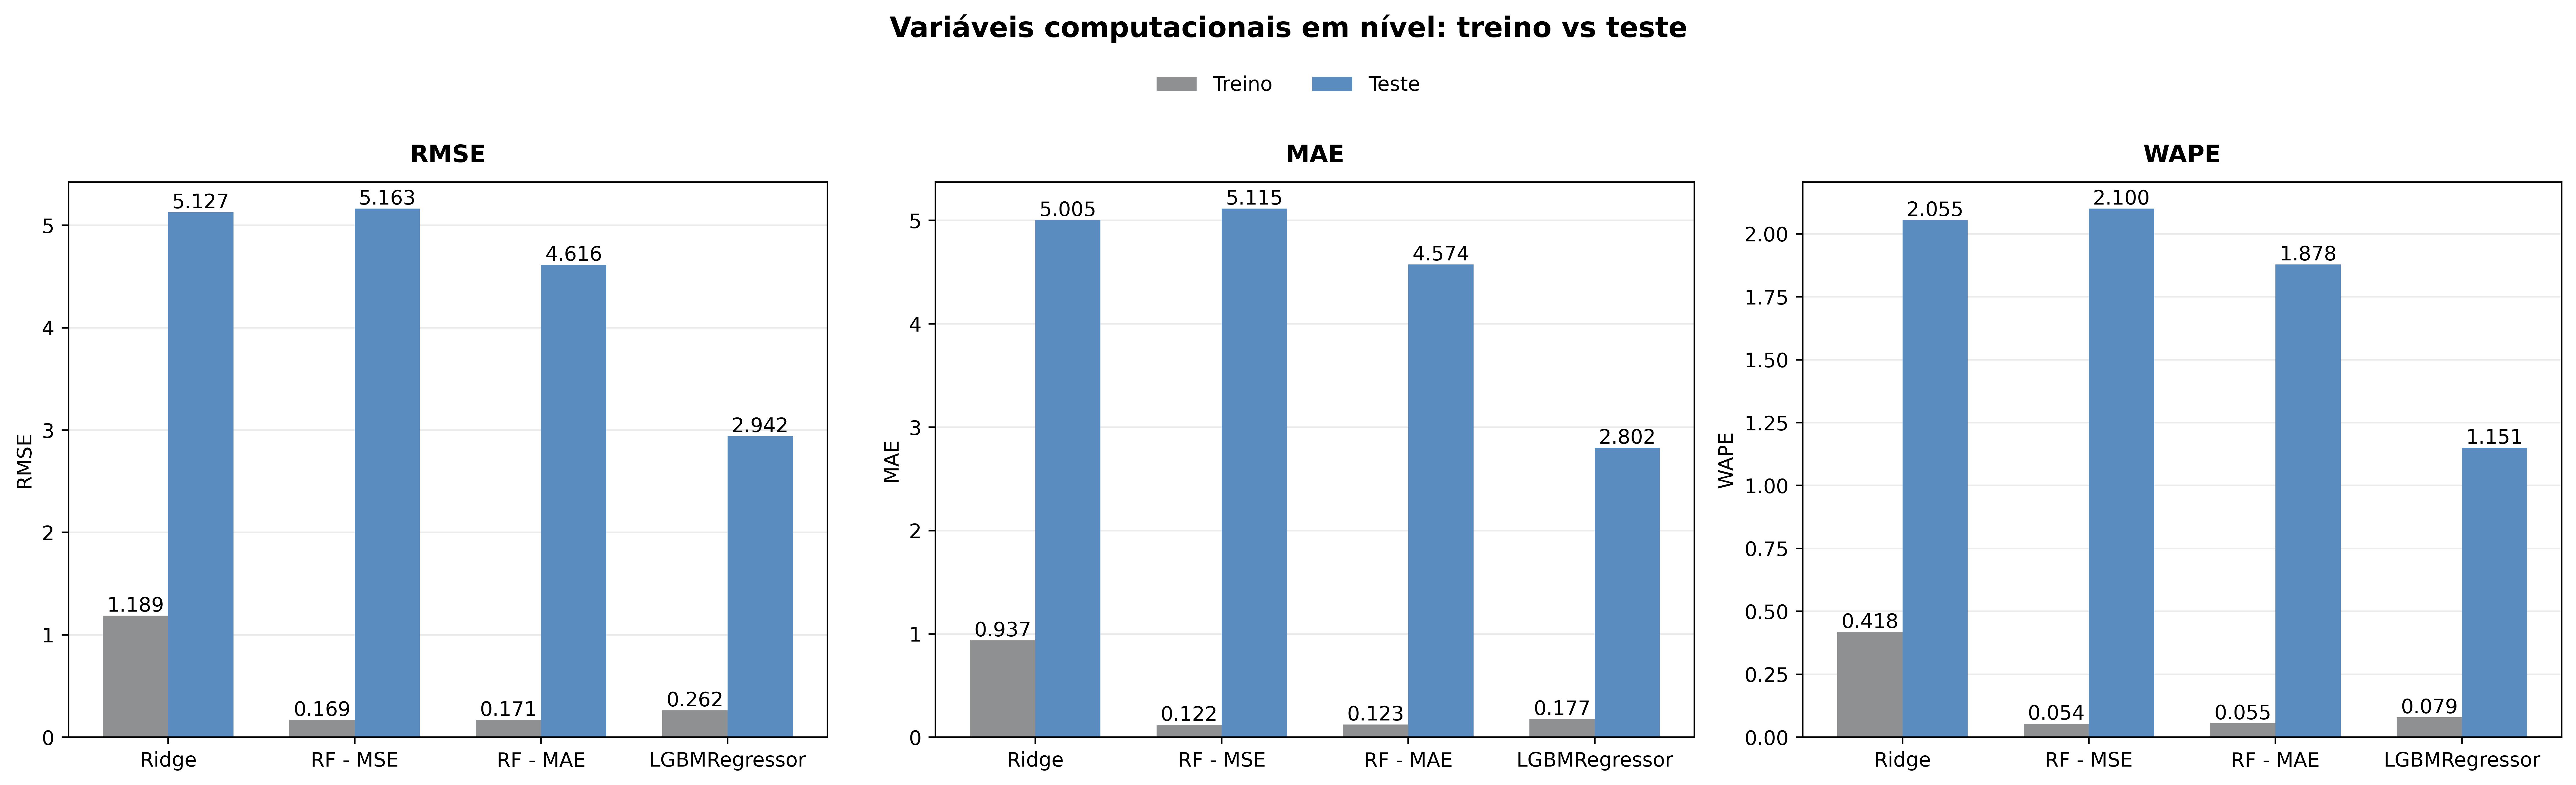

In [12]:
fig = plot_metric_comparison(train, test, "Variáveis computacionais em nível: treino vs teste")

In [13]:
fig.savefig("../Imagens/Variáveis computacionais em nível.png", dpi=500, bbox_inches='tight')

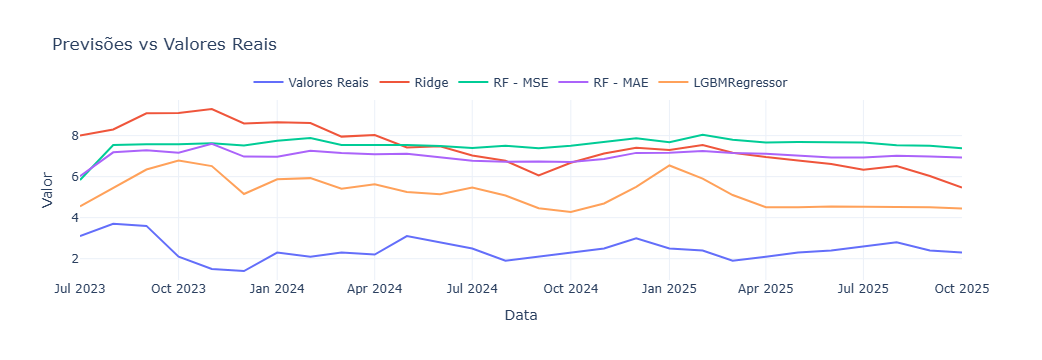

In [14]:
plot_predictions(df_test[target], preds)

## Best model with the computational variables using lags [except target lags]

In [15]:
var_lags = {'GS1_fred-md': [10],
 'GS5_fred-md': [12],
 'OILPRICEx_fred-md_Eur': [1, 2, 3, 4, 5, 6, 7, 12],
 'CUSR0000SAC_fred-md': [1, 2, 11, 12],
 'PCEPI_fred-md': [12],
 'EMPENT_PT_ea-qd': [12],
 'REER42_PT_ea-md': [6, 7, 8, 9, 10, 11, 12],
 'HICPOV_PT_ea-md': [12],
 'HICPNEF_PT_ea-md': [12],
 'HICPSV_PT_ea-md': [12],
 'HICPNG_PT_ea-md': [1, 3, 4, 12],
 'DFGDP_PT_ea-qd': [12],
 'CCONFIX_PT_ea-md': [1, 2, 11, 12],
 'epu_pt_epu': [6, 7, 8],
 'GDP_PT_ea-qd': [1, 2, 3, 4, 5, 12],
 'ULCIN_PT_ea-qd': [12],
 'EXPGS_PT_ea-qd': [12],
 'IMPGS_PT_ea-qd': [2, 3],
 'CCI_PT_ea-md': [12],
 'UNETOT_PT_ea-md': [12],
 'PPIPT_ppi': [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12]}


In [16]:
def get_lags(variables, lags):
    my_lags = list()
    for key, value in var_lags.items():
        if key in variables:
            for v in value:
                if v <= lags:
                    my_lags.append(f'{key}_lag_{v}')

    return my_lags

In [17]:
def rank_models_by_average_test_rank(lag_performance_df):
    ranked_df = lag_performance_df.copy()

    ranked_df["rank_test_wape"] = ranked_df["test_wape"].rank(
        method="min",
        ascending=True,
    )

    ranked_df["rank_test_rmse"] = ranked_df["test_rmse"].rank(
        method="min",
        ascending=True,
    )

    ranked_df["rank_test_mae"] = ranked_df["test_mae"].rank(
        method="min",
        ascending=True,
    )

    ranked_df["Overfitting?"] = (
        ranked_df["test_mae"] > ranked_df["train_mae"] * 2
        ) | (
        ranked_df["test_rmse"] > ranked_df["train_rmse"] * 2
        )

    ranked_df["rank_medio"] = ranked_df[
        ["rank_test_wape", "rank_test_rmse", "rank_test_mae"]
    ].mean(axis=1)

    ranked_df = (
        ranked_df
        .sort_values(["rank_medio", "test_rmse", "test_mae"])
        .reset_index(drop=True)
    )

    return ranked_df

In [18]:
def plot_top5_lag_model_metrics(lag_performance_ranked_df):
    top5_models = lag_performance_ranked_df.head(5).copy()

    metric_labels = ["MAE", "RMSE", "WAPE"]
    train_cols = ["train_mae", "train_rmse", "train_wape"]
    test_cols = ["test_mae", "test_rmse", "test_wape"]

    for _, row in top5_models.iterrows():
        model_name = row["model"]
        lag = row["lag"]
        overfitting = row["Overfitting?"]

        train_values = [row[col] for col in train_cols]
        test_values = [row[col] for col in test_cols]

        x = np.arange(len(metric_labels))
        width = 0.35

        fig, ax = plt.subplots(figsize=(10, 6))

        bars_train = ax.bar(
            x - width / 2,
            train_values,
            width,
            label="treino fitted",
            color="#5B7DBE",
        )

        bars_test = ax.bar(
            x + width / 2,
            test_values,
            width,
            label="teste forecast",
            color="#E88B39",
        )

        ax.set_title(f"{model_name} - lag {lag}: Treino vs Teste (Overfitting? - {overfitting})", fontsize=14)
        ax.set_ylabel("Valor")
        ax.set_xticks(x)
        ax.set_xticklabels(metric_labels)
        ax.grid(axis="y", alpha=0.4, linestyle="--")
        ax.legend()

        for bars in [bars_train, bars_test]:
            for bar in bars:
                height = bar.get_height()
                bar_color = bar.get_facecolor()

                ax.annotate(
                    f"{height:.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                    fontweight="bold",
                    color=bar_color,
                )

        fig.tight_layout()
        plt.show()

In [19]:
lag_performance = {}

for lag in range(1, 13):
    my_lags1 = get_lags(computational_variables, lag)
    scores_train, scores_test, preds, _ = build_model(computational_variables + my_lags1, lag)

    lag_performance[lag] = {
        "train": scores_train,
        "test": scores_test,
    }

lag_performance_rows = []

for lag, lag_results in lag_performance.items():
    for model_name in lag_results["train"].keys():
        row = {
            "lag": lag,
            "model": model_name,
            "train_wape": lag_results["train"][model_name]["wape"],
            "train_rmse": lag_results["train"][model_name]["rmse"],
            "train_mae": lag_results["train"][model_name]["mae"],
            "test_wape": lag_results["test"][model_name]["wape"],
            "test_rmse": lag_results["test"][model_name]["rmse"],
            "test_mae": lag_results["test"][model_name]["mae"],
        }

        lag_performance_rows.append(row)

lag_performance_df = pd.DataFrame(lag_performance_rows)
print("Primeiros modelos construídos:")
display(lag_performance_df.head(4))

lag_performance_ranked_df = rank_models_by_average_test_rank(lag_performance_df)
print("Top 4 melhores modelos:")
display(lag_performance_ranked_df.head(4))

Primeiros modelos construídos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae
0,1,Ridge,0.416,1.174,0.933,1.872,4.715,4.560
1,1,RF - MSE,0.052,0.156,0.117,1.927,4.786,4.693
2,1,RF - MAE,0.057,0.182,0.129,1.740,4.314,4.238
3,1,LGBMRegressor,0.076,0.259,0.171,1.199,3.058,2.921


Top 4 melhores modelos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae,rank_test_wape,rank_test_rmse,rank_test_mae,Overfitting?,rank_medio
0,10,Ridge,0.323,0.903,0.719,0.554,1.798,1.349,1.0,2.0,1.0,False,1.333333
1,11,Ridge,0.282,0.797,0.626,0.618,1.747,1.506,2.0,1.0,2.0,True,1.666667
2,12,Ridge,0.107,0.302,0.237,0.984,2.520,2.396,3.0,4.0,3.0,True,3.333333
3,12,LGBMRegressor,0.046,0.165,0.102,0.986,2.506,2.402,4.0,3.0,4.0,True,3.666667


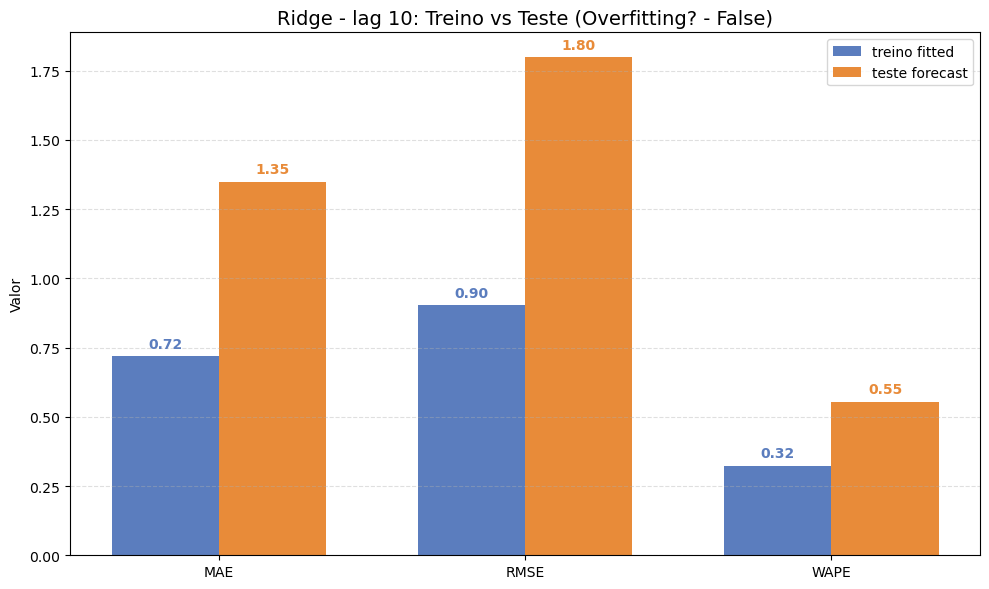

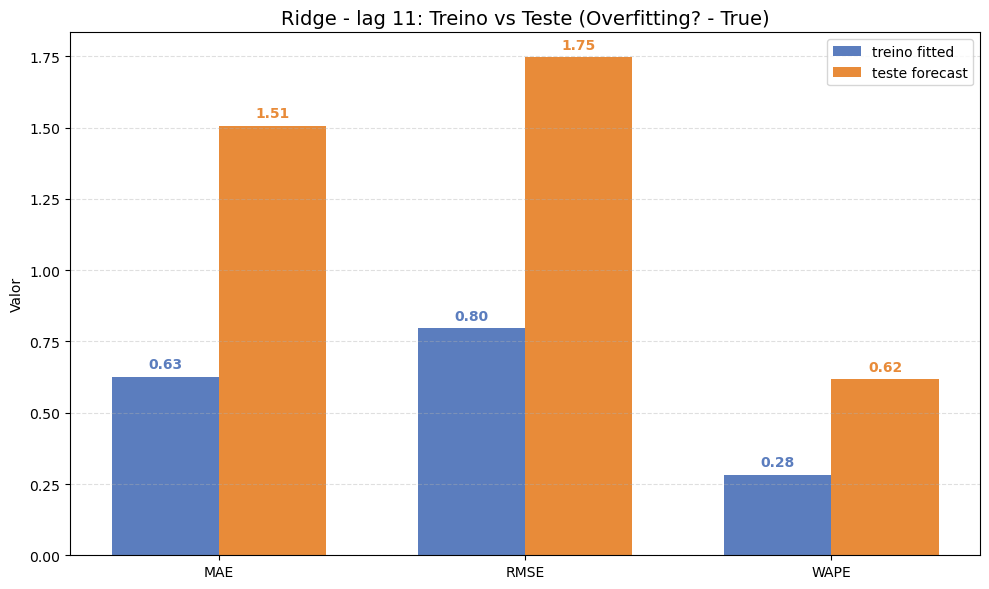

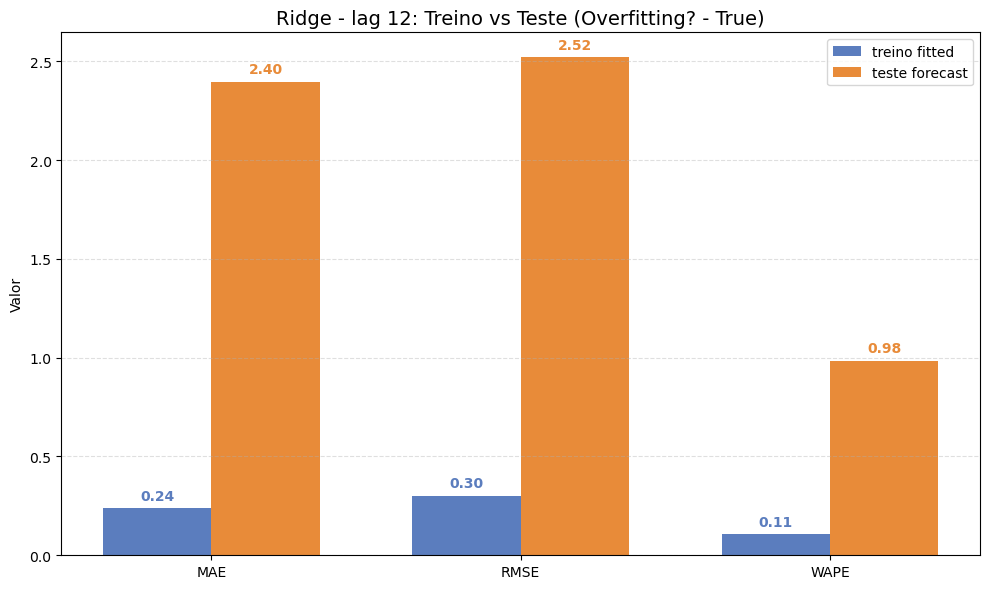

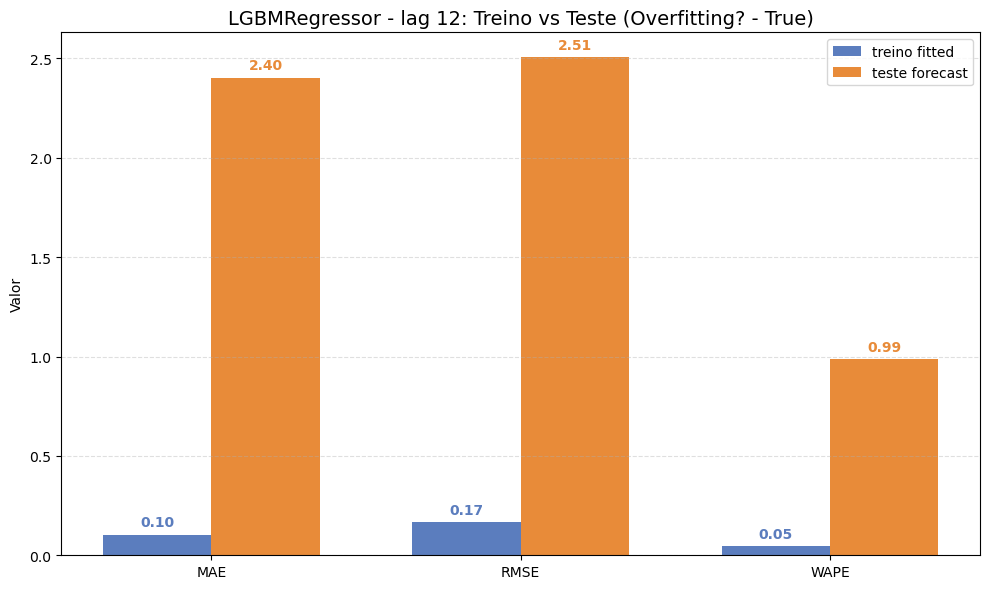

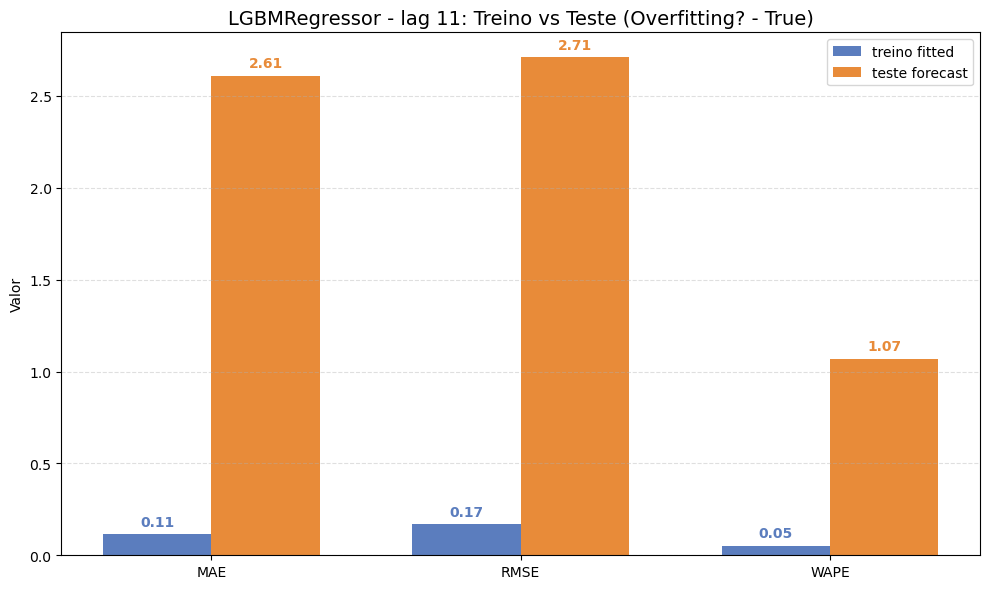

In [20]:
plot_top5_lag_model_metrics(lag_performance_ranked_df)

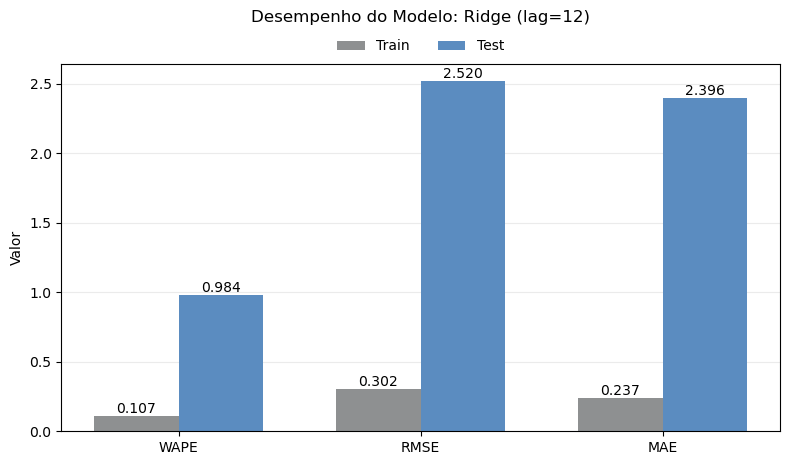

In [21]:
def plot_single_model_performance(row, path):
    metrics = ['wape', 'rmse', 'mae']

    colors = {"Treino": "#8E9091", "Teste": "#5B8CC0"}
    
    train_values = [row[f'train_{m}'] for m in metrics]
    test_values = [row[f'test_{m}'] for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars_train = ax.bar(x - width/2, train_values, width, label='Train', color=colors["Treino"])
    bars_test = ax.bar(x + width/2, test_values, width, label='Test', color=colors["Teste"])

    ax.set_xticks(x, [m.upper() for m in metrics])
    ax.set_ylabel('Valor')
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.set_title(f"Desempenho do Modelo: {row['model']} (lag={row['lag']})", pad=30)
    # ax.legend()

    # Valores por cima das barras
    for bar in list(bars_train) + list(bars_test):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.3f}', ha='center', va='bottom')

    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.10),
        ncol=2,
        frameon=False,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(f"../Imagens/{path}.png", dpi=500, bbox_inches='tight')

plot_single_model_performance(lag_performance_ranked_df.iloc[2], 'melhor modelo sem lags da alvo')

## Model with the computational variables with the first selected lag

In [22]:
lag_min = [f'{key}_lag_{value[0]}' for key, value in var_lags.items() if key in computational_variables]
lag_min

['GS1_fred-md_lag_10',
 'GS5_fred-md_lag_12',
 'OILPRICEx_fred-md_Eur_lag_1',
 'CUSR0000SAC_fred-md_lag_1',
 'PCEPI_fred-md_lag_12',
 'EMPENT_PT_ea-qd_lag_12',
 'REER42_PT_ea-md_lag_6',
 'HICPOV_PT_ea-md_lag_12',
 'HICPNEF_PT_ea-md_lag_12',
 'HICPSV_PT_ea-md_lag_12',
 'HICPNG_PT_ea-md_lag_1',
 'DFGDP_PT_ea-qd_lag_12',
 'CCONFIX_PT_ea-md_lag_1']

In [23]:
train, test, preds, _ = build_model(lag_min + computational_variables, 12)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.371,0.137,0.153,0.212
mae,0.292,0.101,0.107,0.139
wape,0.132,0.046,0.048,0.063


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,1.444,4.568,4.012,2.709
mae,1.212,4.477,3.940,2.603
wape,0.497,1.838,1.617,1.069


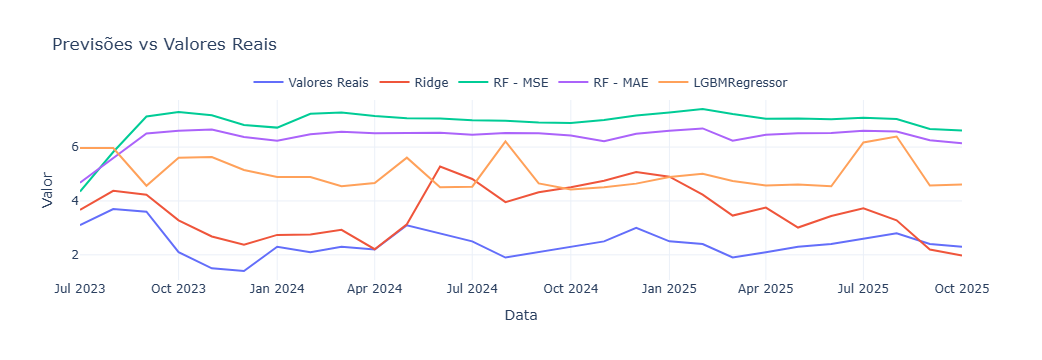

In [24]:
plot_predictions(df_test[target], preds)

## Model with the computational variables with the last selected lag

In [25]:
lag_max = [f'{key}_lag_{value[-1]}' for key, value in var_lags.items() if key in computational_variables]
lag_max

['GS1_fred-md_lag_10',
 'GS5_fred-md_lag_12',
 'OILPRICEx_fred-md_Eur_lag_12',
 'CUSR0000SAC_fred-md_lag_12',
 'PCEPI_fred-md_lag_12',
 'EMPENT_PT_ea-qd_lag_12',
 'REER42_PT_ea-md_lag_12',
 'HICPOV_PT_ea-md_lag_12',
 'HICPNEF_PT_ea-md_lag_12',
 'HICPSV_PT_ea-md_lag_12',
 'HICPNG_PT_ea-md_lag_12',
 'DFGDP_PT_ea-qd_lag_12',
 'CCONFIX_PT_ea-md_lag_12']

In [26]:
train, test, preds, _ = build_model(lag_max + computational_variables, 12)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.337,0.149,0.15,0.183
mae,0.272,0.104,0.11,0.120
wape,0.123,0.047,0.05,0.054


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,2.098,4.929,4.031,3.041
mae,1.994,4.890,3.985,2.955
wape,0.818,2.008,1.636,1.213


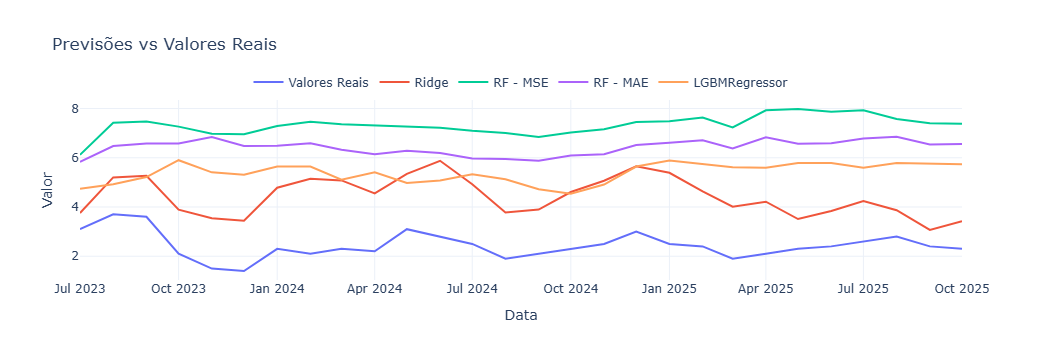

In [27]:
plot_predictions(df_test[target], preds)

# Adding target lag

## Simple model only with the first target lag

In [28]:
target_lag = ['inflation_target_lag_1',]
train, test, preds, _  = build_model(target_lag, 1)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.419,0.341,0.343,0.667
mae,0.300,0.258,0.254,0.393
wape,0.134,0.115,0.113,0.176


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.478,0.552,0.528,0.517
mae,0.363,0.418,0.398,0.391
wape,0.149,0.172,0.163,0.160


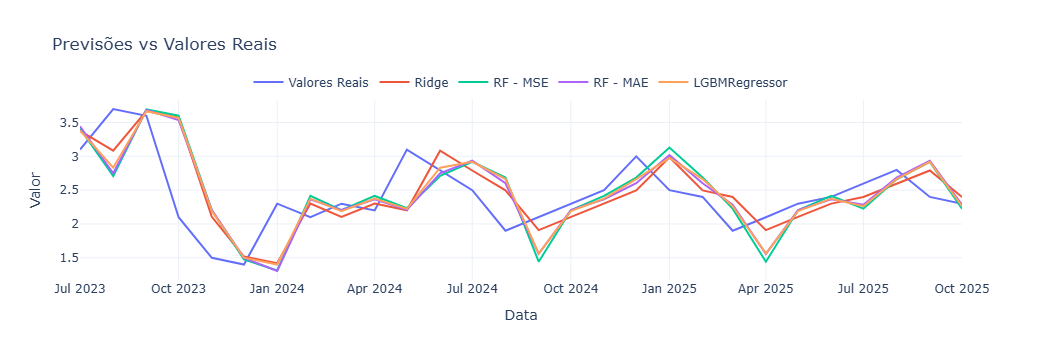

In [29]:
plot_predictions(df_test[target], preds)

## Using the first selected lags with first target lag

In [30]:
train, test, preds, _ = build_model(computational_variables + lag_min + target_lag, 12)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.269,0.153,0.150,0.200
mae,0.201,0.112,0.109,0.128
wape,0.091,0.050,0.049,0.058


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.559,3.725,2.414,1.174
mae,0.436,3.416,2.189,1.013
wape,0.179,1.402,0.899,0.416


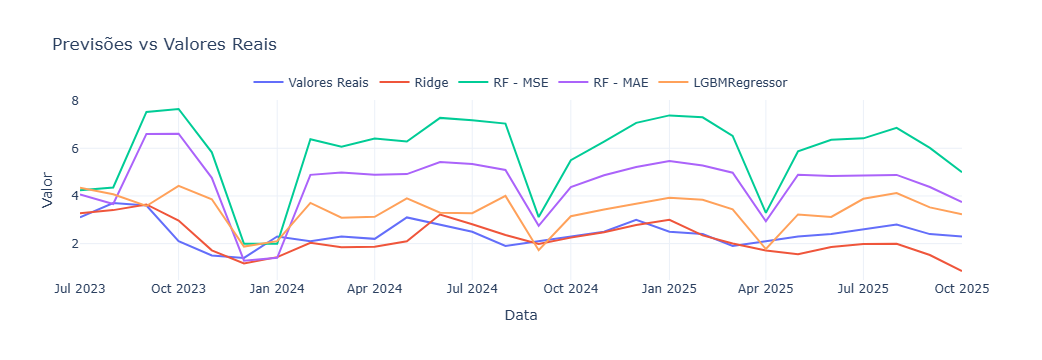

In [31]:
plot_predictions(df_test[target], preds)

## Using the last selected lags with first target lag

In [32]:
train, test, preds, _ = build_model(computational_variables + lag_max + target_lag, 12)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.243,0.155,0.149,0.183
mae,0.183,0.110,0.108,0.112
wape,0.083,0.050,0.049,0.051


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.492,2.578,1.544,1.343
mae,0.386,2.365,1.403,1.187
wape,0.159,0.971,0.576,0.487


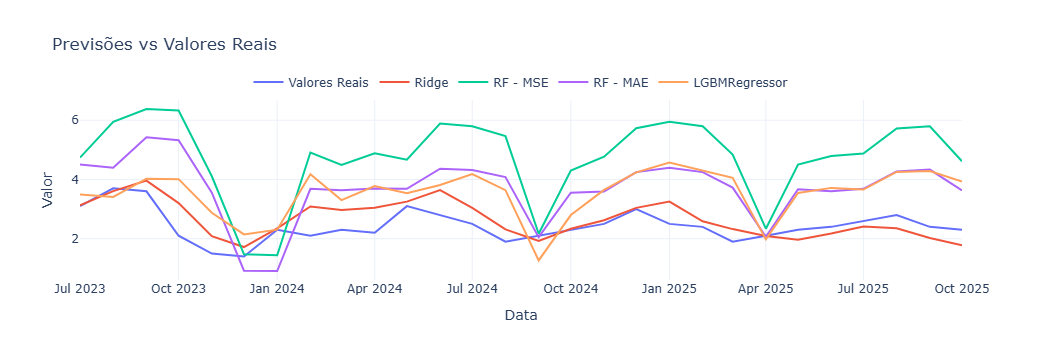

In [33]:
plot_predictions(df_test[target], preds)

## Best model with the computational variables using lags [including target lags]

In [34]:
lag_performance = {}

for lag in range(1, 13):
    my_lags1 = get_lags(computational_variables, lag)
    scores_train, scores_test, preds, _ = build_model(computational_variables + my_lags1 + target_lag, lag)

    lag_performance[lag] = {
        "train": scores_train,
        "test": scores_test,
    }

lag_performance_rows = []

for lag, lag_results in lag_performance.items():
    for model_name in lag_results["train"].keys():
        row = {
            "lag": lag,
            "model": model_name,
            "train_wape": lag_results["train"][model_name]["wape"],
            "train_rmse": lag_results["train"][model_name]["rmse"],
            "train_mae": lag_results["train"][model_name]["mae"],
            "test_wape": lag_results["test"][model_name]["wape"],
            "test_rmse": lag_results["test"][model_name]["rmse"],
            "test_mae": lag_results["test"][model_name]["mae"],
        }

        lag_performance_rows.append(row)

lag_performance_df = pd.DataFrame(lag_performance_rows)

print("Primeiros modelos construídos:")
display(lag_performance_df.head(4))

lag_performance_ranked_df = rank_models_by_average_test_rank(lag_performance_df)
print("Top 4 melhores modelos:")
display(lag_performance_ranked_df.head(4))

Primeiros modelos construídos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae
0,1,Ridge,0.114,0.341,0.256,0.172,0.508,0.418
1,1,RF - MSE,0.050,0.156,0.112,1.275,3.419,3.105
2,1,RF - MAE,0.051,0.159,0.115,0.879,2.350,2.141
3,1,LGBMRegressor,0.066,0.228,0.149,0.491,1.359,1.197


Top 4 melhores modelos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae,rank_test_wape,rank_test_rmse,rank_test_mae,Overfitting?,rank_medio
0,12,Ridge,0.078,0.232,0.174,0.144,0.460,0.351,1.0,1.0,1.0,True,1.0
1,11,Ridge,0.105,0.307,0.233,0.150,0.492,0.365,2.0,2.0,2.0,False,2.0
2,1,Ridge,0.114,0.341,0.256,0.172,0.508,0.418,3.0,3.0,3.0,False,3.0
3,9,Ridge,0.109,0.323,0.242,0.176,0.569,0.428,4.0,7.0,4.0,False,5.0


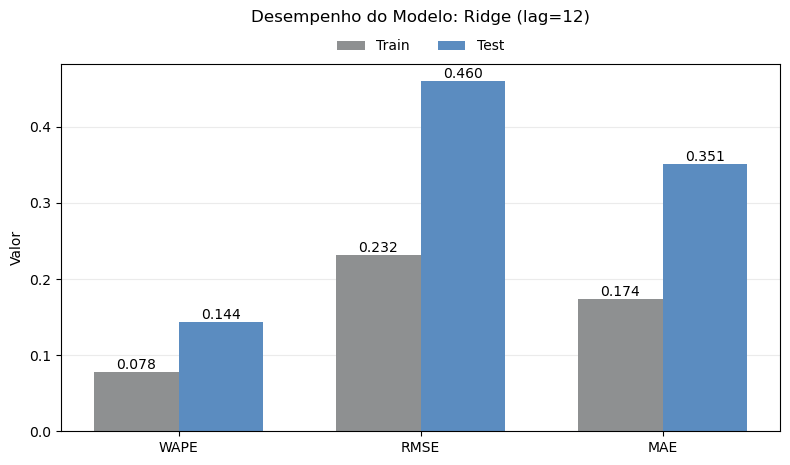

In [35]:
plot_single_model_performance(lag_performance_ranked_df.iloc[0], 'melhor modelo com lags da alvo')

### Testing the best model

In [141]:
my_lags12 = get_lags(computational_variables, 12)

train, test, preds, models = build_model(computational_variables + my_lags12 + target_lag, 12)
model = models['Ridge']

In [142]:
print("Melhor modelo - Treino")
display(pd.DataFrame(train)[["Ridge"]].T)
print("Melhor modelo - Teste")
display(pd.DataFrame(test)[["Ridge"]].T)

Melhor modelo - Treino


,rmse,mae,wape
Ridge,0.232,0.174,0.078


Melhor modelo - Teste


,rmse,mae,wape
Ridge,0.46,0.351,0.144


In [143]:
preds

{'Ridge': array([3.09426662, 3.64452138, 3.90221363, 3.10406078, 2.03053108,
        1.5554391 , 2.316301  , 3.12003303, 2.87768763, 3.00032082,
        3.15498079, 3.60766599, 3.05509809, 2.40356909, 1.91912082,
        2.4795502 , 2.71590405, 3.03900071, 3.22103322, 2.60315756,
        2.23407015, 2.11128418, 2.04662494, 2.2299329 , 2.52060832,
        2.47758055, 2.1749183 , 1.80799142]),
 'RF - MSE': array([4.051, 4.135, 7.335, 7.326, 5.531, 1.923, 1.656, 6.433, 5.736,
        6.209, 5.894, 7.048, 7.242, 6.88 , 2.624, 5.263, 6.217, 6.87 ,
        7.175, 6.993, 6.18 , 2.834, 5.552, 6.065, 6.108, 6.699, 5.964,
        4.96 ]),
 'RF - MAE': array([4.046, 3.661, 6.147, 6.286, 4.428, 1.061, 0.913, 4.44 , 4.416,
        4.384, 4.46 , 5.127, 5.199, 4.816, 2.395, 4.139, 4.466, 4.795,
        5.08 , 4.917, 4.603, 2.694, 4.562, 4.488, 4.563, 4.77 , 4.545,
        3.876]),
 'LGBMRegressor': array([4.19808156, 3.97556699, 3.97960541, 4.5301704 , 3.62274596,
        2.10848429, 2.5047415 , 4.44

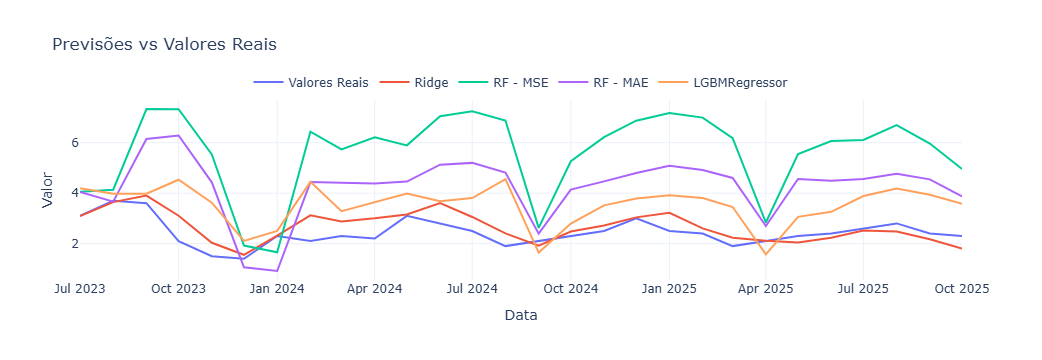

In [139]:
plot_predictions(df_test[target], preds)

In [39]:
importances = dict()

for key, idx in zip(model.feature_names_in_, model.coef_):
    importances[key] = idx

importances = pd.Series(importances)

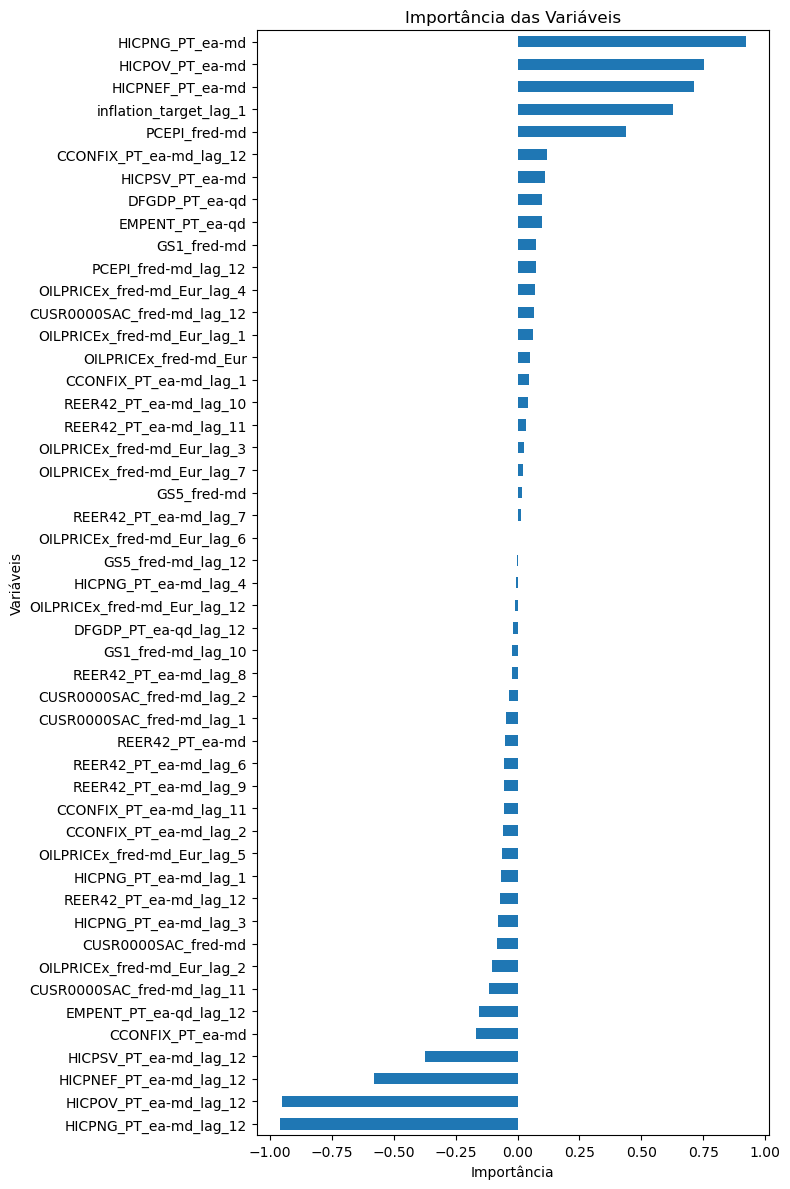

In [40]:
import matplotlib.pyplot as plt

# Ordenar (opcional, mas recomendado)
importances_sorted = importances.sort_values()

plt.figure(figsize=(8, 12))
importances_sorted.plot(kind='barh')  # horizontal fica mais legível

plt.title('Importância das Variáveis')
plt.xlabel('Importância')
plt.ylabel('Variáveis')

plt.tight_layout()
plt.show()

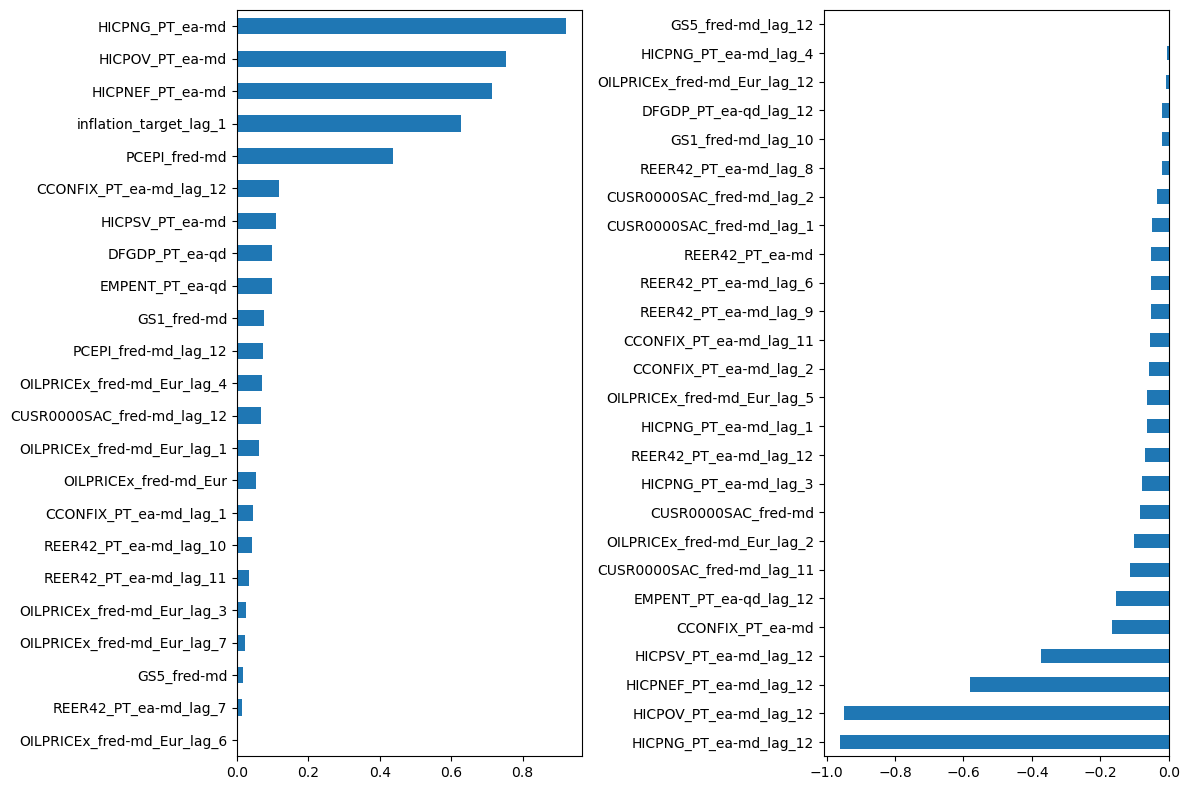

In [41]:
import matplotlib.pyplot as plt

# Ordenar (opcional, mas recomendado)
importances_sorted = importances.sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

importances_sorted.loc[importances_sorted >= 0].plot(kind='barh', ax=ax1)  # horizontal fica mais legível
importances_sorted.loc[importances_sorted < 0].plot(kind='barh', ax=ax2)  # horizontal fica mais legível

# plt.title('Importância das Variáveis')
# plt.xlabel('Importância')
# plt.ylabel('Variáveis')

plt.tight_layout()
plt.show()

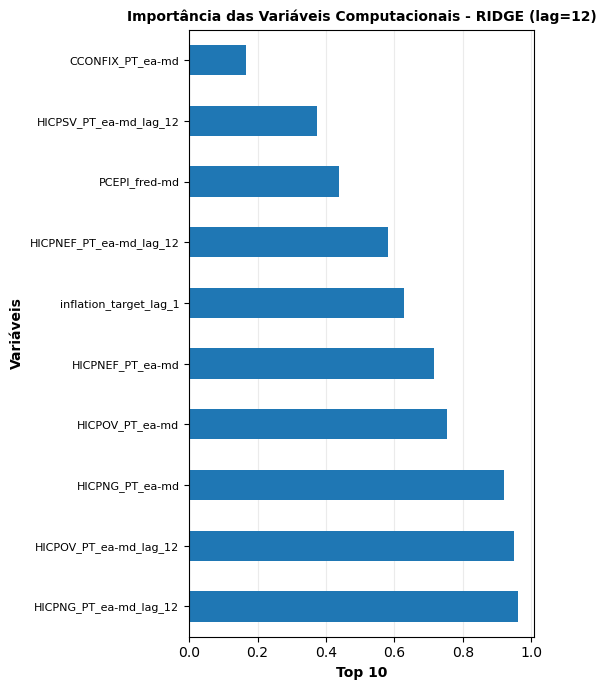

In [ ]:
importances_sorted = abs(importances).sort_values(ascending=False).head(10)

plt.figure(figsize=(6, 7))
importances_sorted.head(10).plot(kind='barh')  # horizontal fica mais legível

plt.title('Importância das Variáveis Computacionais - RIDGE (lag=12)', fontdict=dict(fontweight='bold', fontsize=10))
plt.xlabel('Top 10', fontdict=dict(fontweight='bold'))
plt.ylabel('Variáveis', fontdict=dict(fontweight='bold'))

plt.grid(axis="x", alpha=0.25)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.yticks(fontsize=8)
plt.show()

In [44]:
abs(importances).describe()

count    49.000000
mean      0.176962
std       0.268982
min       0.000874
25%       0.035174
50%       0.065477
75%       0.113408
max       0.959579
dtype: float64

In [45]:
new_vars = importances.loc[abs(importances) > 0.05].index

In [46]:
len(new_vars)

33

### Testing the best model with the most important features

In [47]:
train, test, preds, models = build_model(new_vars, 12)
model = models['Ridge']

In [48]:
print("Melhor modelo - Treino")
display(pd.DataFrame(train)[["Ridge"]].T)
print("Melhor modelo - Teste")
display(pd.DataFrame(test)[["Ridge"]].T)

Melhor modelo - Treino


,rmse,mae,wape
Ridge,0.233,0.174,0.079


Melhor modelo - Teste


,rmse,mae,wape
Ridge,0.465,0.352,0.145


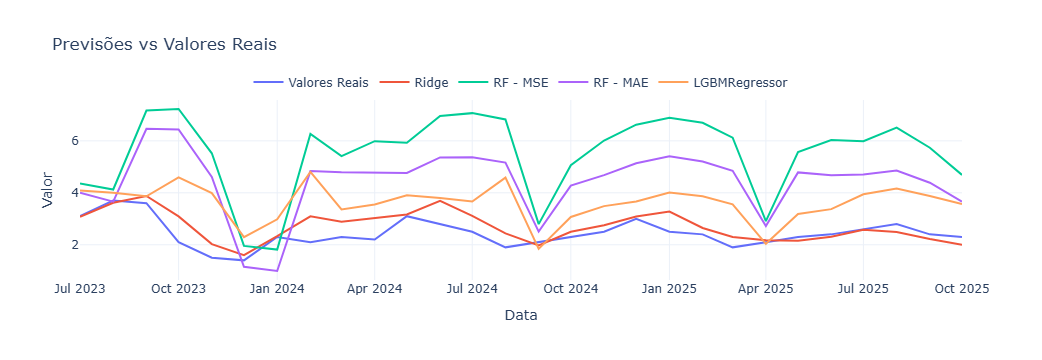

In [49]:
plot_predictions(df_test[target], preds)

# Using all the variables in level

In [50]:
all_columns = [col for col in df_train.columns if '_lag_' not in col and col != target]
all_columns

['HICPOV_PT_ea-md',
 'HICPNEF_PT_ea-md',
 'HICPSV_PT_ea-md',
 'HICPNG_PT_ea-md',
 'GS5_fred-md',
 'CCONFIX_PT_ea-md',
 'REER42_PT_ea-md',
 'EMPENT_PT_ea-qd',
 'PCEPI_fred-md',
 'EXPGS_PT_ea-qd',
 'IMPGS_PT_ea-qd',
 'CCI_PT_ea-md',
 'UNETOT_PT_ea-md',
 'GS1_fred-md',
 'PPIPT_ppi',
 'ULCIN_PT_ea-qd',
 'GDP_PT_ea-qd',
 'CUSR0000SAC_fred-md',
 'epu_pt_epu',
 'DFGDP_PT_ea-qd',
 'OILPRICEx_fred-md_Eur']

In [51]:
train, test, preds, _ = build_model(all_columns)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.676,0.147,0.135,0.200
mae,0.553,0.105,0.100,0.135
wape,0.247,0.047,0.045,0.060


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,3.145,4.378,2.690,2.560
mae,2.914,4.329,2.510,2.487
wape,1.196,1.777,1.031,1.021


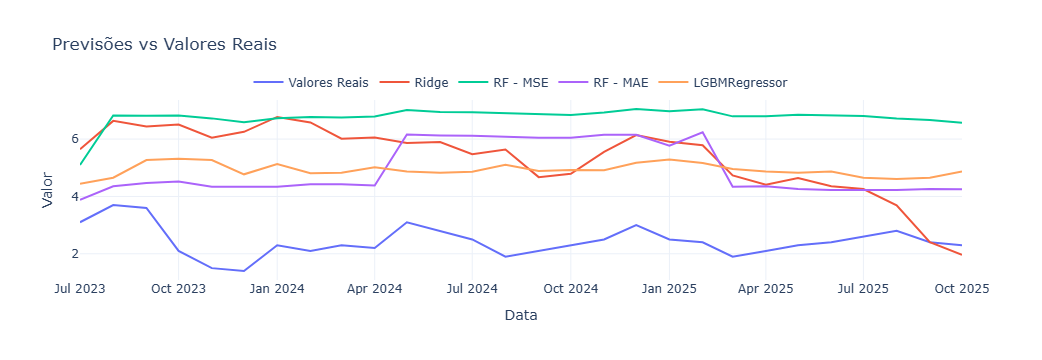

In [52]:
plot_predictions(df_test[target], preds)

# Best models using all the variables [without target lag]

In [53]:
lag_performance = {}

for lag in range(1, 13):
    my_lags1 = get_lags(all_columns, lag)
    scores_train, scores_test, preds, _ = build_model(all_columns + my_lags1, lag)

    lag_performance[lag] = {
        "train": scores_train,
        "test": scores_test,
    }

lag_performance_rows = []

for lag, lag_results in lag_performance.items():
    for model_name in lag_results["train"].keys():
        row = {
            "lag": lag,
            "model": model_name,
            "train_wape": lag_results["train"][model_name]["wape"],
            "train_rmse": lag_results["train"][model_name]["rmse"],
            "train_mae": lag_results["train"][model_name]["mae"],
            "test_wape": lag_results["test"][model_name]["wape"],
            "test_rmse": lag_results["test"][model_name]["rmse"],
            "test_mae": lag_results["test"][model_name]["mae"],
        }

        lag_performance_rows.append(row)

lag_performance_df = pd.DataFrame(lag_performance_rows)

print("Primeiros modelos construídos:")
display(lag_performance_df.head(4))

lag_performance_ranked_df = rank_models_by_average_test_rank(lag_performance_df)
print("Top 4 melhores modelos:")
display(lag_performance_ranked_df.head(4))

Primeiros modelos construídos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae
0,1,Ridge,0.248,0.674,0.555,1.314,3.420,3.200
1,1,RF - MSE,0.044,0.131,0.098,1.580,3.946,3.847
2,1,RF - MAE,0.046,0.139,0.104,0.803,2.296,1.957
3,1,LGBMRegressor,0.055,0.196,0.124,1.060,2.680,2.582


Top 4 melhores modelos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae,rank_test_wape,rank_test_rmse,rank_test_mae,Overfitting?,rank_medio
0,11,LGBMRegressor,0.039,0.146,0.086,0.203,0.626,0.494,1.0,1.0,1.0,True,1.0
1,10,LGBMRegressor,0.040,0.151,0.090,0.266,0.793,0.647,2.0,2.0,2.0,True,2.0
2,12,LGBMRegressor,0.035,0.138,0.077,0.306,0.893,0.745,3.0,3.0,3.0,True,3.0
3,12,RF - MSE,0.047,0.137,0.103,0.332,0.902,0.808,4.0,4.0,4.0,True,4.0


## Testing the best model

In [54]:
# train, test, model = build_lag_model4(11)
my_lags1 = get_lags(all_columns, 11)
train, test, preds, models = build_model(all_columns + my_lags1, 11)

# model = models['LGBMRegressor']

In [55]:
lgbm_importance = dict()

for key, idx in zip(models['LGBMRegressor'].feature_name_, models['LGBMRegressor'].feature_importances_):
    lgbm_importance[key] = idx

lgbm_importance = pd.Series(lgbm_importance)
lgbm_importance.sort_values(ascending=False)

PPIPT_ppi                      55
PPIPT_ppi_lag_1                33
OILPRICEx_fred-md_Eur_lag_3    29
epu_pt_epu_lag_8               28
OILPRICEx_fred-md_Eur_lag_4    28
                               ..
HICPNG_PT_ea-md_lag_1           3
GDP_PT_ea-qd                    3
HICPNEF_PT_ea-md                3
HICPNG_PT_ea-md_lag_4           2
HICPNG_PT_ea-md_lag_3           1
Length: 64, dtype: int32

In [56]:
print("Melhor modelo - Treino")
display(pd.DataFrame(train)[["LGBMRegressor"]].T)
print("Melhor modelo - Teste")
display(pd.DataFrame(test)[["LGBMRegressor"]].T)

Melhor modelo - Treino


,rmse,mae,wape
LGBMRegressor,0.146,0.086,0.039


Melhor modelo - Teste


,rmse,mae,wape
LGBMRegressor,0.626,0.494,0.203


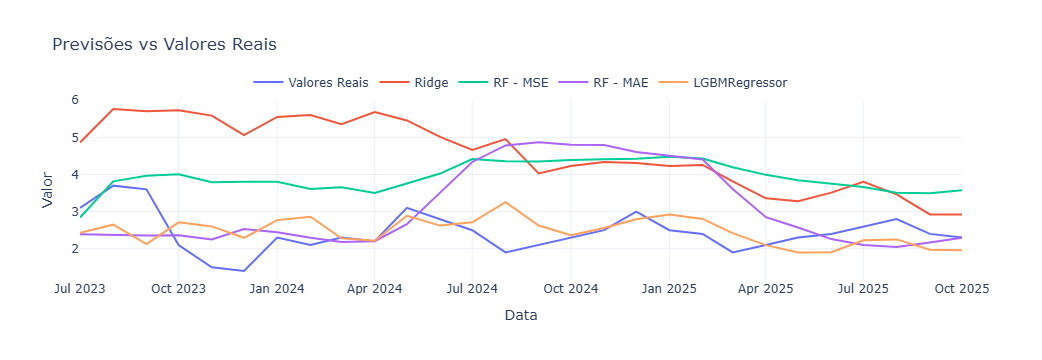

In [57]:
plot_predictions(df_test[target], preds)

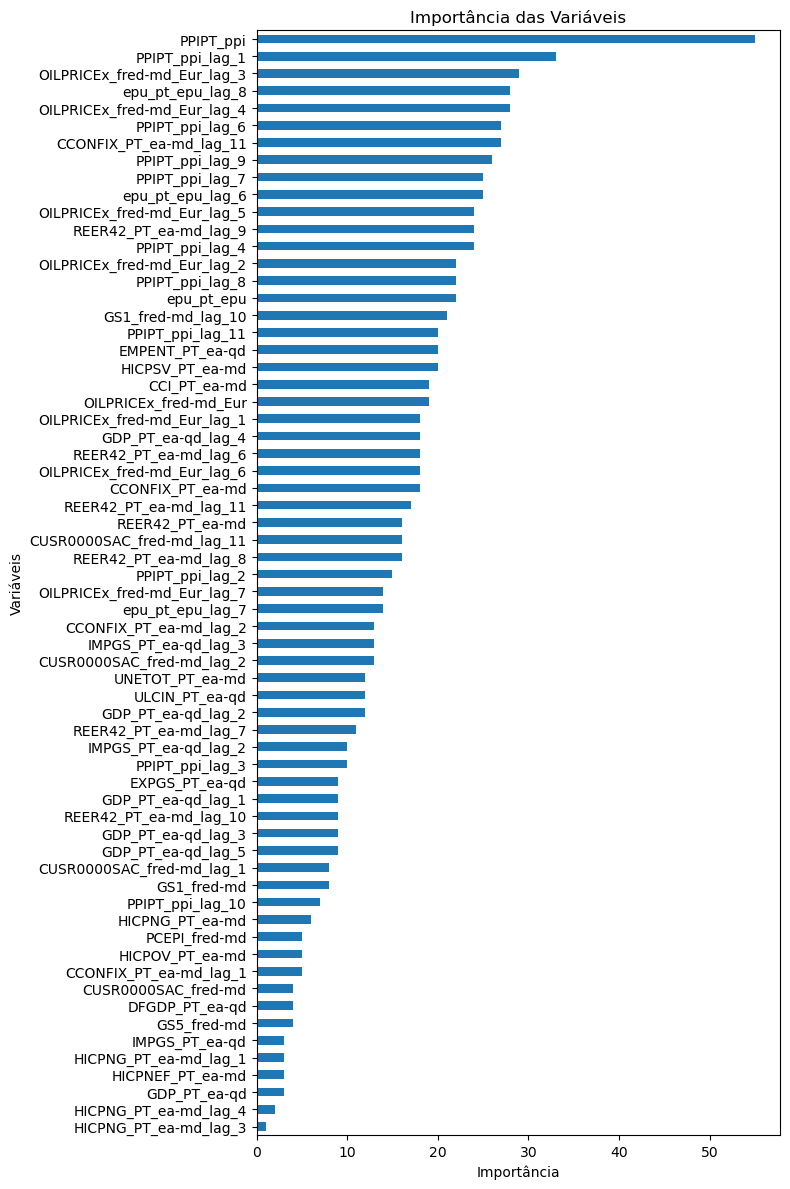

In [58]:
# Ordenar (opcional, mas recomendado)
importances_sorted = lgbm_importance.sort_values()

plt.figure(figsize=(8, 12))
importances_sorted.plot(kind='barh')  # horizontal fica mais legível

plt.title('Importância das Variáveis')
plt.xlabel('Importância')
plt.ylabel('Variáveis')

plt.tight_layout()
plt.show()

# Selecting the best model using all variables with lags [including target lag]

In [59]:
lag_performance = {}

for lag in range(1, 13):
    my_lags1 = get_lags(all_columns, lag)
    scores_train, scores_test, preds, _ = build_model(all_columns + my_lags1 + target_lag, lag)

    lag_performance[lag] = {
        "train": scores_train,
        "test": scores_test,
    }

lag_performance_rows = []

for lag, lag_results in lag_performance.items():
    for model_name in lag_results["train"].keys():
        row = {
            "lag": lag,
            "model": model_name,
            "train_wape": lag_results["train"][model_name]["wape"],
            "train_rmse": lag_results["train"][model_name]["rmse"],
            "train_mae": lag_results["train"][model_name]["mae"],
            "test_wape": lag_results["test"][model_name]["wape"],
            "test_rmse": lag_results["test"][model_name]["rmse"],
            "test_mae": lag_results["test"][model_name]["mae"],
        }

        lag_performance_rows.append(row)

lag_performance_df = pd.DataFrame(lag_performance_rows)

print("Primeiros modelos construídos:")
display(lag_performance_df.head(4))

lag_performance_ranked_df = rank_models_by_average_test_rank(lag_performance_df)
print("Top 4 melhores modelos:")
display(lag_performance_ranked_df.head(4))

Primeiros modelos construídos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae
0,1,Ridge,0.108,0.315,0.242,0.182,0.562,0.443
1,1,RF - MSE,0.047,0.145,0.105,1.267,3.430,3.087
2,1,RF - MAE,0.048,0.147,0.107,0.940,2.494,2.289
3,1,LGBMRegressor,0.056,0.200,0.125,0.379,1.031,0.924


Top 4 melhores modelos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae,rank_test_wape,rank_test_rmse,rank_test_mae,Overfitting?,rank_medio
0,12,Ridge,0.072,0.210,0.159,0.175,0.514,0.427,1.0,1.0,1.0,True,1.000000
1,1,Ridge,0.108,0.315,0.242,0.182,0.562,0.443,2.0,2.0,2.0,False,2.000000
2,3,Ridge,0.104,0.308,0.234,0.186,0.567,0.452,4.0,3.0,3.0,False,3.333333
3,2,Ridge,0.106,0.312,0.238,0.185,0.573,0.452,3.0,4.0,3.0,False,3.333333


## Testing the best model

In [60]:
my_lags1 = get_lags(all_columns, 12)
train, test, preds, models = build_model(all_columns + my_lags1 + target_lag, 12)

In [61]:
lgbm_importance = dict()

for key, idx in zip(models['Ridge'].feature_names_in_, models['Ridge'].coef_):
    lgbm_importance[key] = idx

lgbm_importance = pd.Series(lgbm_importance)
lgbm_importance.sort_values(ascending=False)

HICPNG_PT_ea-md            0.902752
HICPOV_PT_ea-md            0.670238
HICPNEF_PT_ea-md           0.620144
inflation_target_lag_1     0.610244
PCEPI_fred-md              0.364133
                             ...   
HICPSV_PT_ea-md_lag_12    -0.395793
EXPGS_PT_ea-qd_lag_12     -0.406429
HICPNEF_PT_ea-md_lag_12   -0.589951
HICPOV_PT_ea-md_lag_12    -0.819560
HICPNG_PT_ea-md_lag_12    -0.844936
Length: 83, dtype: float64

In [62]:
print("Melhor modelo - Treino")
display(pd.DataFrame(train)[["Ridge"]].T)
print("Melhor modelo - Teste")
display(pd.DataFrame(test)[["Ridge"]].T)

Melhor modelo - Treino


,rmse,mae,wape
Ridge,0.21,0.159,0.072


Melhor modelo - Teste


,rmse,mae,wape
Ridge,0.514,0.427,0.175


In [63]:
plot_predictions(df_test[target], preds, models_to_plot=['Ridge', 'LGBMRegressor'])

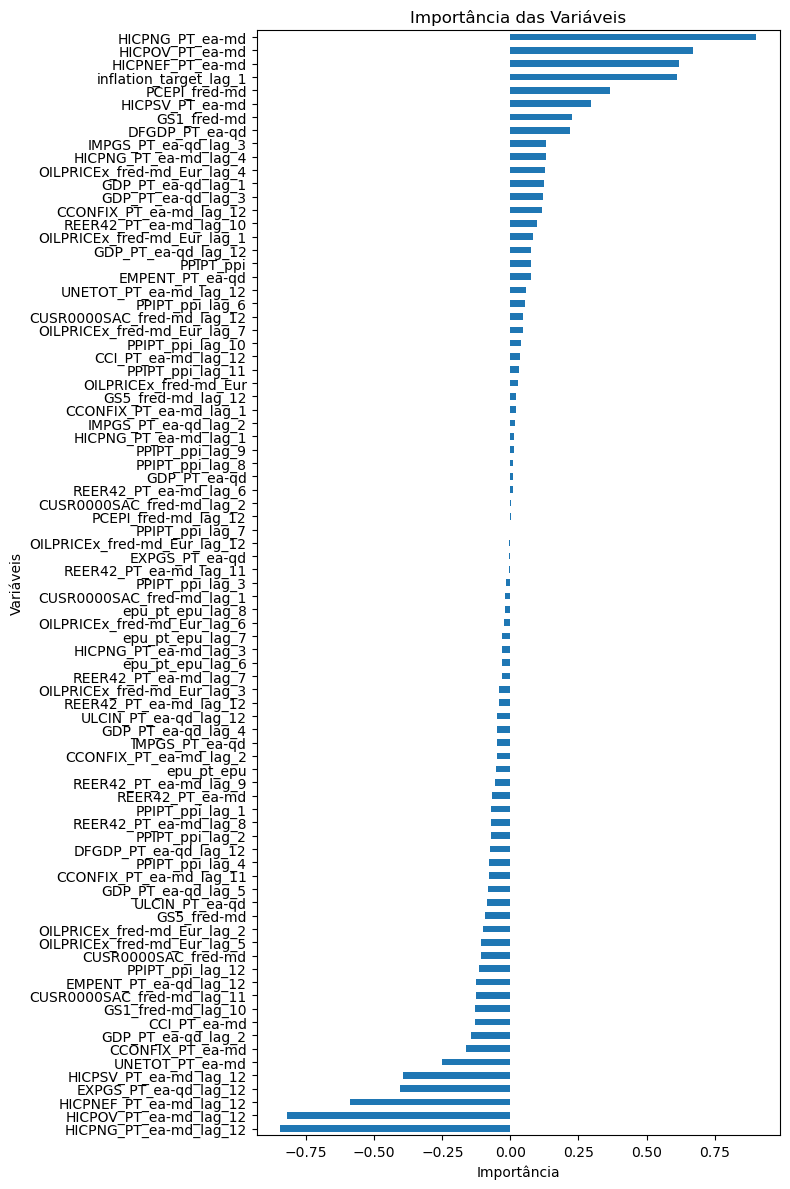

In [64]:
# Ordenar (opcional, mas recomendado)
importances_sorted = lgbm_importance.sort_values()

plt.figure(figsize=(8, 12))
importances_sorted.plot(kind='barh')  # horizontal fica mais legível

plt.title('Importância das Variáveis')
plt.xlabel('Importância')
plt.ylabel('Variáveis')

plt.tight_layout()
plt.show()

# Models with the three first target lags

In [66]:
target_lags = ['inflation_target_lag_1', 'inflation_target_lag_2', 'inflation_target_lag_3']

In [67]:
train, test, preds, _  = build_model(target_lags, 3)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.391,0.205,0.212,0.628
mae,0.295,0.139,0.146,0.356
wape,0.131,0.062,0.065,0.159


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.505,0.498,0.478,0.518
mae,0.379,0.347,0.334,0.394
wape,0.156,0.143,0.137,0.162


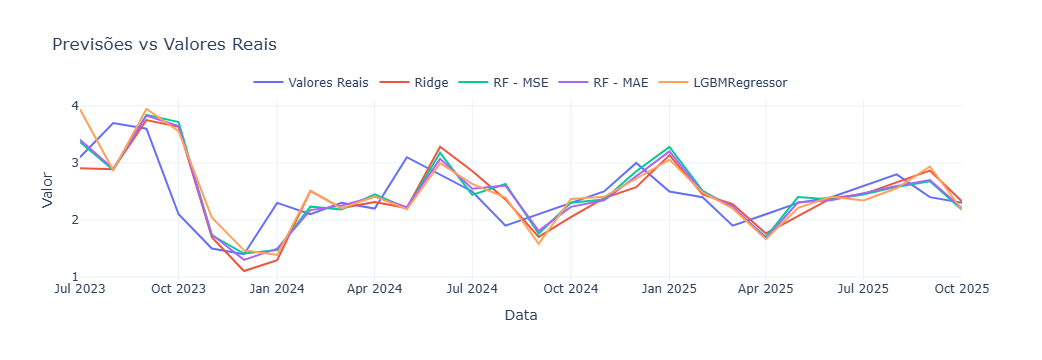

In [68]:
plot_predictions(df_test[target], preds)

## Model with the third target lag

In [72]:
train, test, preds, _  = build_model([target_lags[-1]], 3)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.884,0.657,0.671,0.924
mae,0.614,0.480,0.467,0.637
wape,0.273,0.214,0.208,0.284


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.889,1.103,1.068,0.997
mae,0.649,0.748,0.683,0.673
wape,0.266,0.307,0.281,0.276


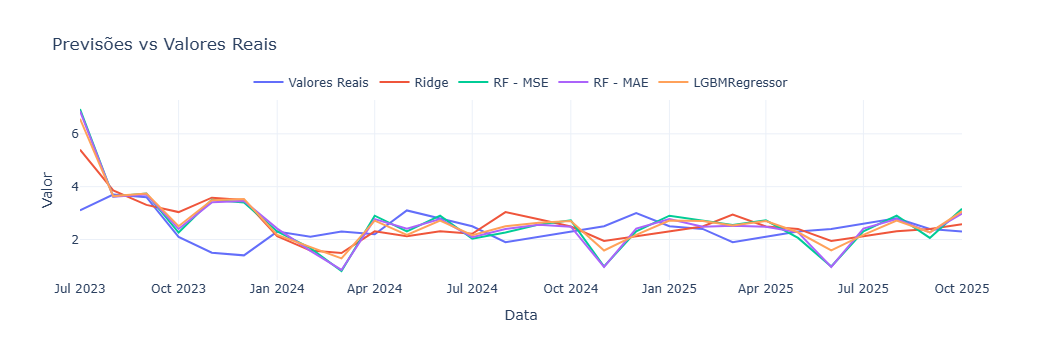

In [73]:
plot_predictions(df_test[target], preds)

# Selecting the best model using all variables with lags [including first three target lag]

In [121]:
lag_performance = {}

for lag in range(3, 13):
    my_lags1 = get_lags(all_columns, lag)
    scores_train, scores_test, preds, _ = build_model(all_columns + my_lags1 + target_lags, lag)

    lag_performance[lag] = {
        "train": scores_train,
        "test": scores_test,
    }

lag_performance_rows = []

for lag, lag_results in lag_performance.items():
    for model_name in lag_results["train"].keys():
        row = {
            "lag": lag,
            "model": model_name,
            "train_wape": lag_results["train"][model_name]["wape"],
            "train_rmse": lag_results["train"][model_name]["rmse"],
            "train_mae": lag_results["train"][model_name]["mae"],
            "test_wape": lag_results["test"][model_name]["wape"],
            "test_rmse": lag_results["test"][model_name]["rmse"],
            "test_mae": lag_results["test"][model_name]["mae"],
        }

        lag_performance_rows.append(row)

lag_performance_df = pd.DataFrame(lag_performance_rows)

print("Primeiros modelos construídos:")
display(lag_performance_df.head(4))

lag_performance_ranked_df = rank_models_by_average_test_rank(lag_performance_df)
print("Top 4 melhores modelos:")
display(lag_performance_ranked_df.head(4))

Primeiros modelos construídos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae
0,3,Ridge,0.104,0.308,0.232,0.185,0.565,0.451
1,3,RF - MSE,0.047,0.149,0.106,1.215,3.227,2.959
2,3,RF - MAE,0.048,0.150,0.107,1.020,2.677,2.484
3,3,LGBMRegressor,0.051,0.181,0.115,0.275,0.798,0.671


Top 4 melhores modelos:


,lag,model,train_wape,train_rmse,train_mae,test_wape,test_rmse,test_mae,rank_test_wape,rank_test_rmse,rank_test_mae,Overfitting?,rank_medio
0,12,Ridge,0.071,0.208,0.158,0.171,0.493,0.416,1.0,1.0,1.0,True,1.000000
1,3,Ridge,0.104,0.308,0.232,0.185,0.565,0.451,2.0,2.0,2.0,False,2.000000
2,11,Ridge,0.098,0.281,0.218,0.191,0.574,0.464,3.0,3.0,3.0,True,3.000000
3,5,Ridge,0.101,0.303,0.226,0.196,0.587,0.478,5.0,4.0,5.0,True,4.666667


# Model with the most important variables from computacional and teorical variables

In [78]:
my_lags12 = get_lags(computational_variables, 12)

train, test, preds, models = build_model(computational_variables + my_lags12 + target_lag, 12)
model = models['Ridge']

importances = dict()

for key, idx in zip(model.feature_names_in_, model.coef_):
    importances[key] = idx

importances = pd.Series(importances)

new_vars_comp = importances.loc[abs(importances) > 0.25].index
new_vars_teoric = ['PPIPT_ppi', 'CCI_PT_ea-md', 'EXPGS_PT_ea-qd', 'epu_pt_epu_lag_6', 'PPIPT_ppi_lag_1']

print(len(new_vars_comp))
print(len(new_vars_teoric))

9
5


In [122]:
train, test, preds, _  = build_model(new_vars_comp.tolist() + new_vars_teoric, 12)

print("Conjunto de Treino:")
display(pd.DataFrame(train))
print("Conjunto de Teste:")
display(pd.DataFrame(test))

Conjunto de Treino:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.257,0.140,0.141,0.220
mae,0.196,0.102,0.103,0.142
wape,0.088,0.046,0.046,0.064


Conjunto de Teste:


,Ridge,RF - MSE,RF - MAE,LGBMRegressor
rmse,0.363,2.154,1.372,0.616
mae,0.308,1.987,1.251,0.506
wape,0.126,0.816,0.514,0.208


In [ ]:
regression_metrics(df_)

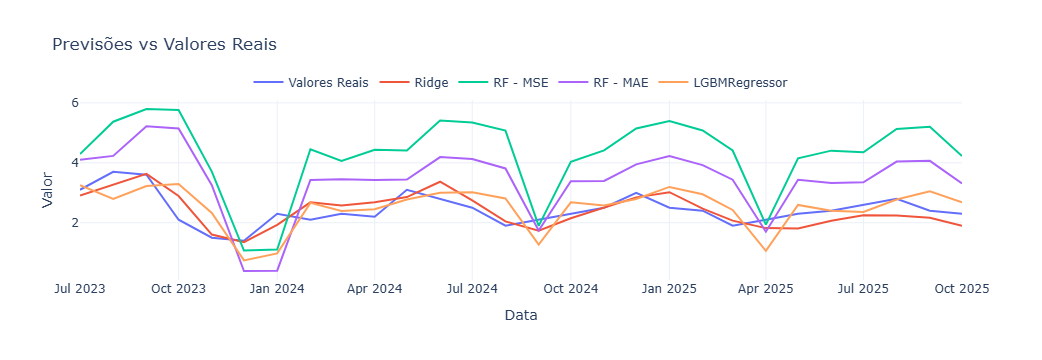

In [123]:
plot_predictions(df_test[target], preds)

In [127]:
model = _['Ridge']
model.feature_names_in_

array(['PCEPI_fred-md', 'HICPOV_PT_ea-md', 'HICPNEF_PT_ea-md',
       'HICPNG_PT_ea-md', 'HICPOV_PT_ea-md_lag_12',
       'HICPNEF_PT_ea-md_lag_12', 'HICPSV_PT_ea-md_lag_12',
       'HICPNG_PT_ea-md_lag_12', 'inflation_target_lag_1', 'PPIPT_ppi',
       'CCI_PT_ea-md', 'EXPGS_PT_ea-qd', 'epu_pt_epu_lag_6',
       'PPIPT_ppi_lag_1'], dtype=object)

In [131]:
best_coefs = pd.Series({key: value for key, value in zip(model.feature_names_in_, model.coef_)})
best_coefs.sort_values(ascending=False)

HICPOV_PT_ea-md            0.872553
HICPNG_PT_ea-md            0.754229
HICPNEF_PT_ea-md           0.720580
inflation_target_lag_1     0.681517
PCEPI_fred-md              0.516889
EXPGS_PT_ea-qd             0.136085
PPIPT_ppi                  0.056416
epu_pt_epu_lag_6          -0.038836
CCI_PT_ea-md              -0.087689
PPIPT_ppi_lag_1           -0.099523
HICPSV_PT_ea-md_lag_12    -0.126467
HICPNG_PT_ea-md_lag_12    -0.915854
HICPNEF_PT_ea-md_lag_12   -0.931730
HICPOV_PT_ea-md_lag_12    -1.117859
dtype: float64

In [ ]:
# modelo naive (média)
regression_metrics(df_test[target], np.zeros(df_test.shape[0]) + df_test[target].mean())

{'rmse': np.float64(0.52), 'mae': 0.386, 'wape': np.float64(0.159)}

In [136]:
(0.36 / 0.52) * 100

69.23076923076923

In [144]:
(0.31 / 0.39) * 100

79.48717948717949

In [145]:
df_test[target].mean()

np.float64(2.4357142857142855)

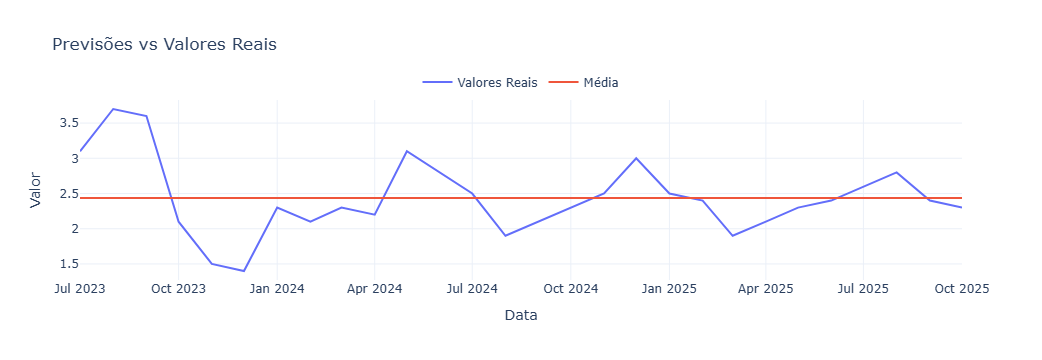

In [147]:
plot_predictions(df_test[target], {'Média': np.zeros(df_test.shape[0]) + df_test[target].mean()})

## Optimizing the best model

In [94]:
# ! pip install optuna


   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------- ----------------------------- 1/4 [colorlog]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   -----------------------

In [95]:
# Python

# Necessary imports
import optuna

In [97]:
X_train = df_train[new_vars_comp.tolist() + new_vars_teoric].iloc[12:]
y_train = df_train[target].iloc[12:]

X_test = df_test[new_vars_comp.tolist() + new_vars_teoric]
y_test = df_test[target]

In [106]:
np.mean([2, 4])

np.float64(3.0)

[I 2026-05-10 23:47:31,898] A new study created in memory with name: no-name-78c4c6da-7de7-4920-b335-d5f1288f5090
C:\Users\josev\AppData\Local\Temp\ipykernel_23192\2587419949.py:4: FutureWarning:

suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.

[I 2026-05-10 23:47:31,926] Trial 0 finished with value: 7.254098360655737 and parameters: {'alpha': 0.002099478173665951}. Best is trial 0 with value: 7.254098360655737.
C:\Users\josev\AppData\Local\Temp\ipykernel_23192\2587419949.py:4: FutureWarning:

suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.

[I 2026-05-10 23:47:31,954] Trial 1 finished with value: 7.106557377049181 and parameters: {'alpha': 0.0035532782164115536}. Best is trial 1 with value: 7.106557377049

Best hyperparameters: {'alpha': 3.8004393783111796}
Train


rmse    0.300
mae     0.227
wape    0.102
dtype: float64

Test


rmse    0.393
mae     0.336
wape    0.138
dtype: float64

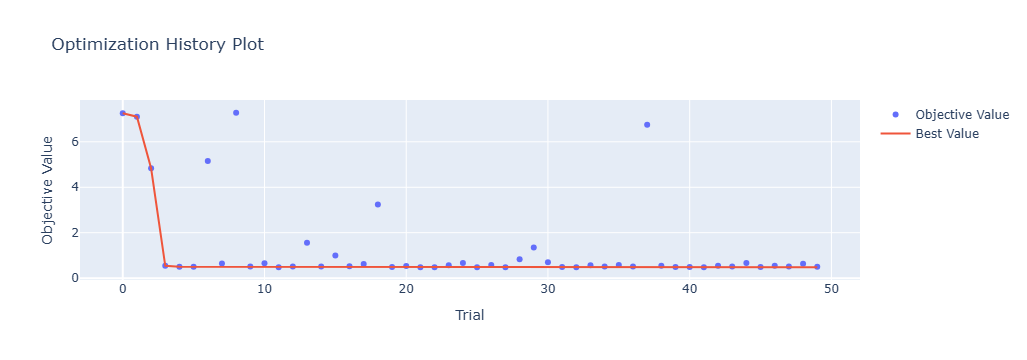

In [118]:
# Define the Optuna objective function
def objective(trial):
    # Suggest hyperparameters for Ridge regression
    alpha = trial.suggest_loguniform('alpha', 1e-3, 100)  # Regularization strength
    
    # Initialize Ridge model with these hyperparameters
    model = Ridge(alpha=alpha, random_state=322)
    
    # Evaluate model using cross-validation
    model.fit(X_train, y_train)

    y_pred = model.predict(X_train)
    rmse_train, mae_train, _ = regression_metrics(y_train, y_pred).values()
    
    y_pred = model.predict(X_test)
    rmse_test, mae_test, _ = regression_metrics(y_test, y_pred).values()
    
    # Optuna minimizes objective by default, so return negative MAE
    return (mae_test - mae_train) / mae_train

# Create Optuna study and optimize
study = optuna.create_study(direction='minimize')  # maximize negative MAE
study.optimize(objective, n_trials=50)

# Print best hyperparameters
print("Best hyperparameters:", study.best_params)

# Train the model with best hyperparameters on the full training set
best_model = Ridge(alpha=study.best_params['alpha'], random_state=322)
best_model.fit(X_train, y_train)

# Evaluate on test set
print("Train")
y_pred = best_model.predict(X_train)
results = regression_metrics(y_train, y_pred)
display(pd.Series(results))
print("Test")
y_pred = best_model.predict(X_test)
results = regression_metrics(y_test, y_pred)
display(pd.Series(results))

# Optional: visualize the optimization history
optuna.visualization.plot_optimization_history(study).show()

[I 2026-05-10 23:48:47,163] A new study created in memory with name: no-name-89c27c1f-290c-47f8-b416-c846f0b49820
[I 2026-05-10 23:48:47,318] Trial 0 finished with value: 0.631 and parameters: {'n_estimators': 162, 'learning_rate': 0.032361186645376676, 'max_depth': 12, 'num_leaves': 207, 'min_child_samples': 36, 'subsample': 0.5598415241548961, 'colsample_bytree': 0.9625481715561159, 'reg_alpha': 1.339517522086231, 'reg_lambda': 0.08373510980013474}. Best is trial 0 with value: 0.631.
[I 2026-05-10 23:48:47,598] Trial 1 finished with value: 0.507 and parameters: {'n_estimators': 717, 'learning_rate': 0.020633283785153143, 'max_depth': 10, 'num_leaves': 295, 'min_child_samples': 52, 'subsample': 0.7492051704424216, 'colsample_bytree': 0.8864303149598183, 'reg_alpha': 0.00015389418719383754, 'reg_lambda': 0.001252446156761338}. Best is trial 1 with value: 0.507.
[I 2026-05-10 23:48:47,764] Trial 2 finished with value: 0.556 and parameters: {'n_estimators': 547, 'learning_rate': 0.006061

Best hyperparameters:
{'n_estimators': 447, 'learning_rate': 0.001204412980506426, 'max_depth': 4, 'num_leaves': 290, 'min_child_samples': 71, 'subsample': 0.9781684765631206, 'colsample_bytree': 0.9991200585694061, 'reg_alpha': 0.004098155216389104, 'reg_lambda': 0.4606907436789526}


rmse    0.416
mae     0.330
wape    0.135
dtype: float64

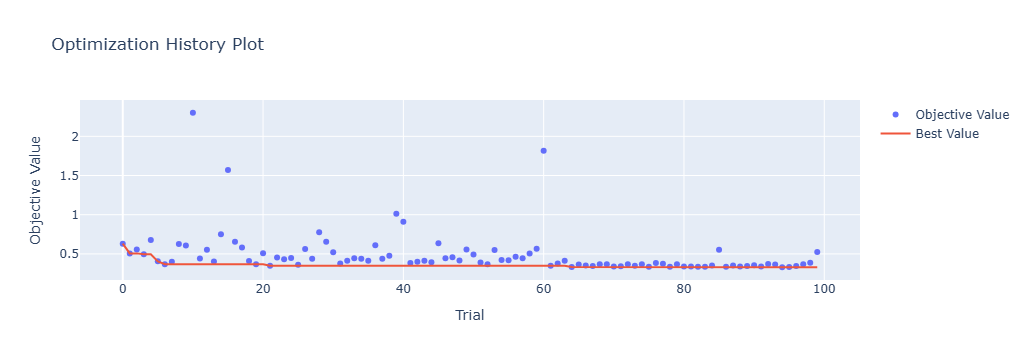

In [119]:
# Define the Optuna objective function
def objective(trial):

    # Hyperparameter search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "num_leaves": trial.suggest_int("num_leaves", 10, 300),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state": 322,
        "verbosity": -1
    }

    # Initialize model
    model = LGBMRegressor(**params)

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    rmse, mae, _ = regression_metrics(y_test, y_pred).values()

    # Minimize average error
    return mae


# Create study
study = optuna.create_study(direction="minimize")

# Optimize
study.optimize(objective, n_trials=100)

# Best parameters
print("Best hyperparameters:")
print(study.best_params)

# Train final model
best_model = LGBMRegressor(
    **study.best_params,
    random_state=322,
    verbosity=-1
)

best_model.fit(X_train, y_train)

# Final evaluation
y_pred = best_model.predict(X_test)

results = regression_metrics(y_test, y_pred)

display(pd.Series(results))

# Optimization history
optuna.visualization.plot_optimization_history(study).show()

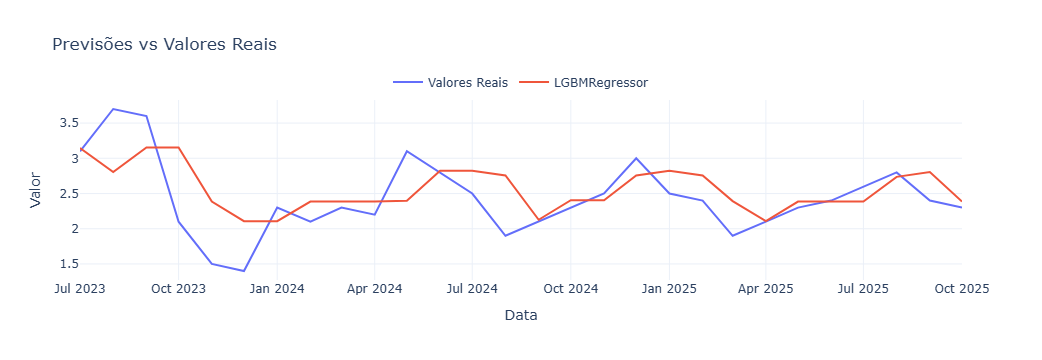

In [115]:
plot_predictions(df_test[target], {'LGBMRegressor': y_pred})